In [19]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from torchvision.models.resnet import Bottleneck

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [21]:

# Transform (convert to tensor + normalize)
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])


# Download and load training set
train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Download and load test set
test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


100%|██████████| 170M/170M [33:40<00:00, 84.4kB/s]   


In [22]:
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [23]:
model = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)


In [24]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [25]:
num_classes = len(train_dataset.classes)
in_features = model.fc.in_features

model.fc = nn.Linear(in_features, num_classes)


In [26]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

fc.weight
fc.bias


In [27]:
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [28]:
weights = models.ResNet152_Weights.DEFAULT
model = model.to(device)

epochs = 3

for epoch in range(epochs):

    #  TRAIN 
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100 * correct / total


    #  VALIDATION 
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = outputs.max(1)

            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_acc = 100 * val_correct / val_total

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}% | Val Acc={val_acc:.2f}%")


Epoch 1: Train Acc=78.43% | Val Acc=83.30%
Epoch 2: Train Acc=83.68% | Val Acc=84.00%
Epoch 3: Train Acc=84.88% | Val Acc=84.36%


In [30]:
from torchvision.models.resnet import Bottleneck

def disable_skip_connections(model, target_layer="layer3", num_blocks=2):
    count = 0

    for name, module in model.named_modules():
        if target_layer in name and isinstance(module, Bottleneck):

            if count >= num_blocks:
                break

            def forward_no_skip(self, x):
                out = self.conv1(x)
                out = self.bn1(out)
                out = self.relu(out)

                out = self.conv2(out)
                out = self.bn2(out)
                out = self.relu(out)

                out = self.conv3(out)
                out = self.bn3(out)

                out = self.relu(out)
                return out

            module.forward = forward_no_skip.__get__(module, Bottleneck)

            print("Disabled skip connection in:", name)
            count += 1


# LOAD MODEL
model = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)

# DISABLE SKIP CONNECTIONS (first 2 blocks of layer3)
disable_skip_connections(model, target_layer="layer3", num_blocks=2)
# REPLACE CLASSIFIER HEAD


model.fc = nn.Linear(model.fc.in_features, 10)


# FREEZE BACKBONE


for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True



# TRAINING SETUP


model = model.to(device)

optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

epochs = 3



# TRAIN + VALIDATE


for epoch in range(epochs):

    #  TRAIN 
    model.train()
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100 * correct / total


    #  VALIDATION 
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = outputs.max(1)

            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_acc = 100 * val_correct / val_total

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}% | Val Acc={val_acc:.2f}%")



Disabled skip connection in: layer3.0
Disabled skip connection in: layer3.1
Epoch 1: Train Acc=16.09% | Val Acc=18.11%
Epoch 2: Train Acc=18.56% | Val Acc=19.44%
Epoch 3: Train Acc=19.38% | Val Acc=19.44%


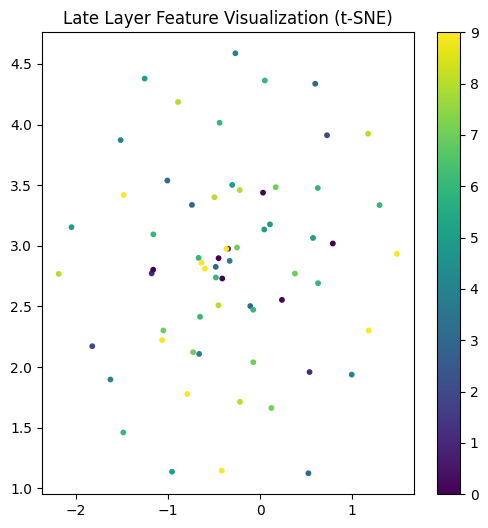

In [31]:
features = {}

def get_hook(name):
    def hook(model, input, output):
        features[name] = output.detach()
    return hook

model.layer1.register_forward_hook(get_hook("early"))
model.layer3.register_forward_hook(get_hook("middle"))
model.layer4.register_forward_hook(get_hook("late"))

model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    _ = model(images)


early_feat = features["early"].mean(dim=[2,3]).cpu()
middle_feat = features["middle"].mean(dim=[2,3]).cpu()
late_feat = features["late"].mean(dim=[2,3]).cpu()

labels = labels[:early_feat.shape[0]]

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)

late_embedded = tsne.fit_transform(late_feat)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(late_embedded[:,0], late_embedded[:,1], c=labels, s=10)
plt.colorbar()
plt.title("Late Layer Feature Visualization (t-SNE)")
plt.show()

